In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Set plot style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Ready. Shape:", df.shape)

Ready. Shape: (421570, 16)


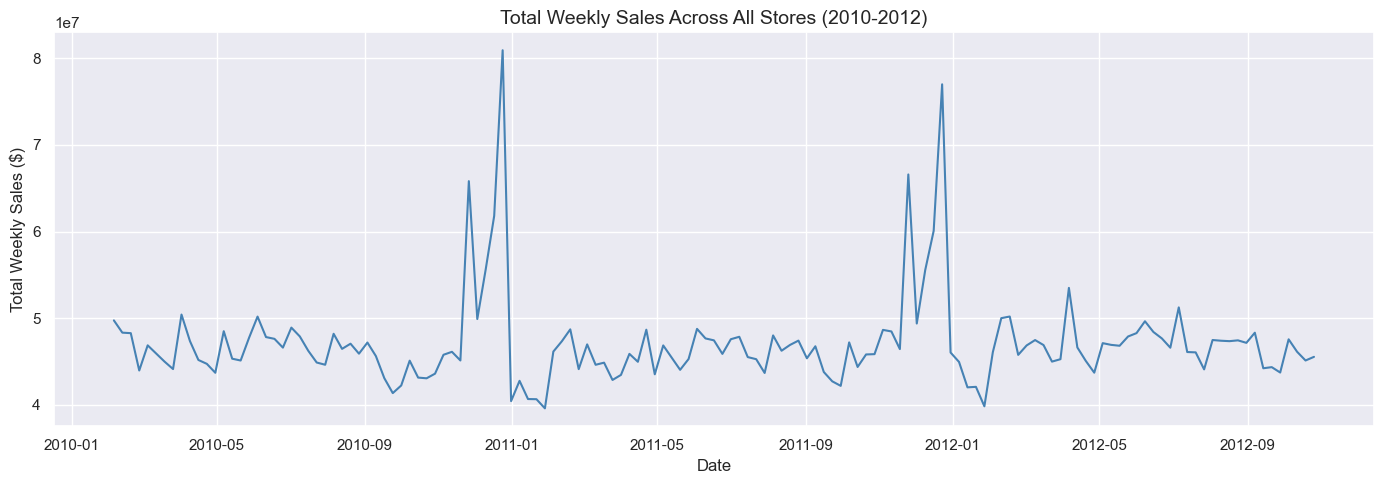

Chart saved


In [2]:
# Aggregate total sales per week across all stores
weekly = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(weekly['Date'], weekly['Weekly_Sales'], color='steelblue', linewidth=1.5)
plt.title('Total Weekly Sales Across All Stores (2010-2012)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/01_weekly_sales_trend.png', dpi=150)
plt.show()
print("Chart saved")

C:\Users\YASHI GILL\AppData\Local\Temp\ipykernel_27688\594229624.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=holiday_avg, x='IsHoliday', y='Weekly_Sales', palette='coolwarm')


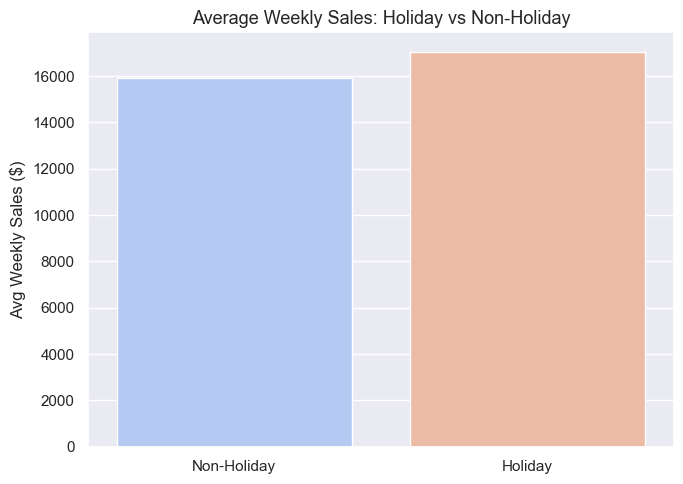

Chart saved


In [3]:
holiday_avg = df.groupby('IsHoliday')['Weekly_Sales'].mean().reset_index()
holiday_avg['IsHoliday'] = holiday_avg['IsHoliday'].map({True: 'Holiday', False: 'Non-Holiday'})

plt.figure(figsize=(7, 5))
sns.barplot(data=holiday_avg, x='IsHoliday', y='Weekly_Sales', palette='coolwarm')
plt.title('Average Weekly Sales: Holiday vs Non-Holiday', fontsize=13)
plt.ylabel('Avg Weekly Sales ($)')
plt.xlabel('')
plt.tight_layout()
plt.savefig('../outputs/02_holiday_impact.png', dpi=150)
plt.show()
print("Chart saved")

C:\Users\YASHI GILL\AppData\Local\Temp\ipykernel_27688\4293053030.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_stores, x='Store', y='Weekly_Sales', palette='viridis')


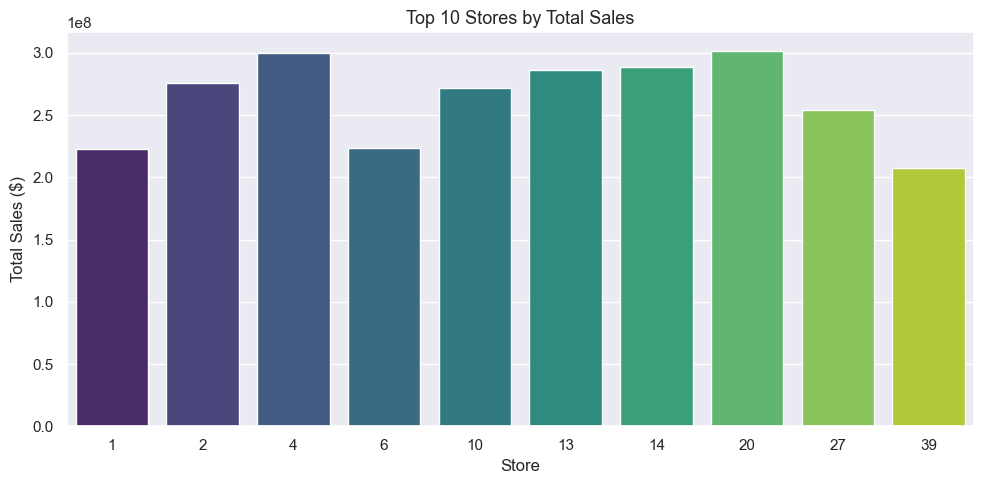

Chart saved


In [4]:
top_stores = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_stores, x='Store', y='Weekly_Sales', palette='viridis')
plt.title('Top 10 Stores by Total Sales', fontsize=13)
plt.ylabel('Total Sales ($)')
plt.xlabel('Store')
plt.tight_layout()
plt.savefig('../outputs/03_top_stores.png', dpi=150)
plt.show()
print("Chart saved")

C:\Users\YASHI GILL\AppData\Local\Temp\ipykernel_27688\2301740851.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Weekly_Sales', palette='Set2')


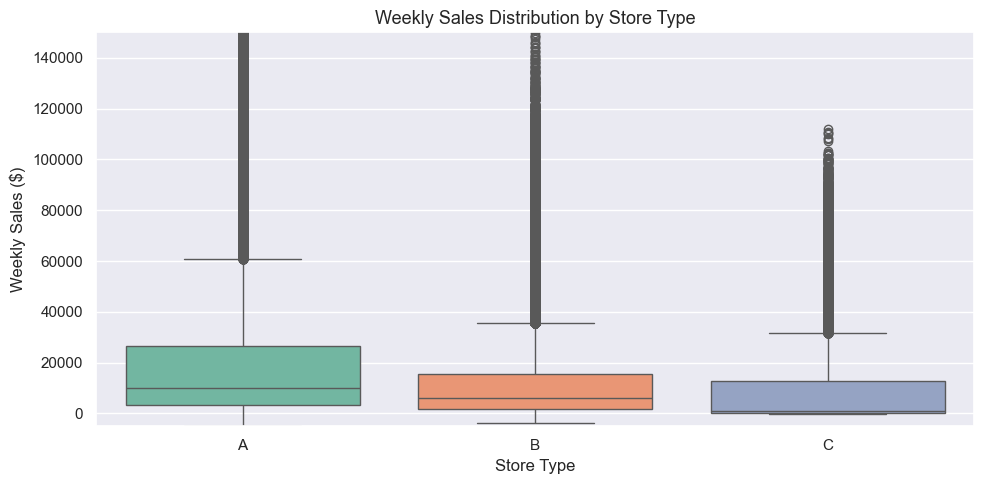

Chart saved


In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Type', y='Weekly_Sales', palette='Set2')
plt.title('Weekly Sales Distribution by Store Type', fontsize=13)
plt.ylabel('Weekly Sales ($)')
plt.xlabel('Store Type')
plt.ylim(-5000, 150000)  # Remove extreme outliers from view
plt.tight_layout()
plt.savefig('../outputs/04_store_type_distribution.png', dpi=150)
plt.show()
print("Chart saved")

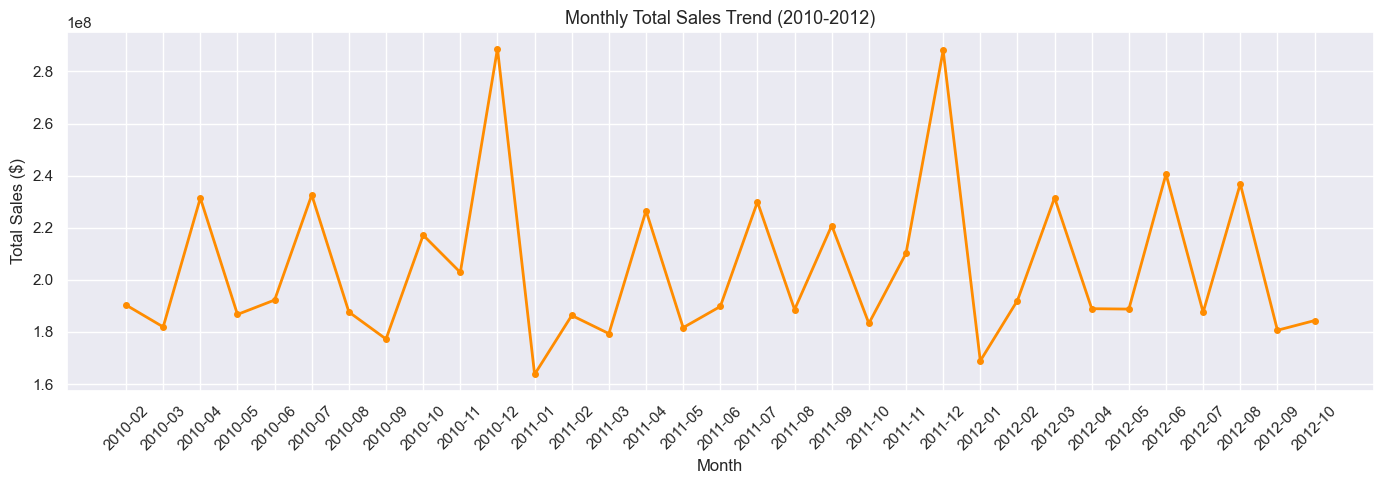

Chart saved


In [6]:
monthly = df.groupby(df['Date'].dt.to_period('M'))['Weekly_Sales'].sum().reset_index()
monthly['Date'] = monthly['Date'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['Date'], monthly['Weekly_Sales'], marker='o', color='darkorange', linewidth=2, markersize=4)
plt.title('Monthly Total Sales Trend (2010-2012)', fontsize=13)
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/05_monthly_trend.png', dpi=150)
plt.show()
print("Chart saved")